<a href="https://colab.research.google.com/github/irynebbie17-cyber/churn-bigml-80.csv-/blob/main/churn_bigml_80_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/churn-bigml-80.csv')
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
print(df.isnull().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [ ]:
df['Total day minutes'] =df['Total day minutes'] .fillna(df['Total day minutes'].mean())

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


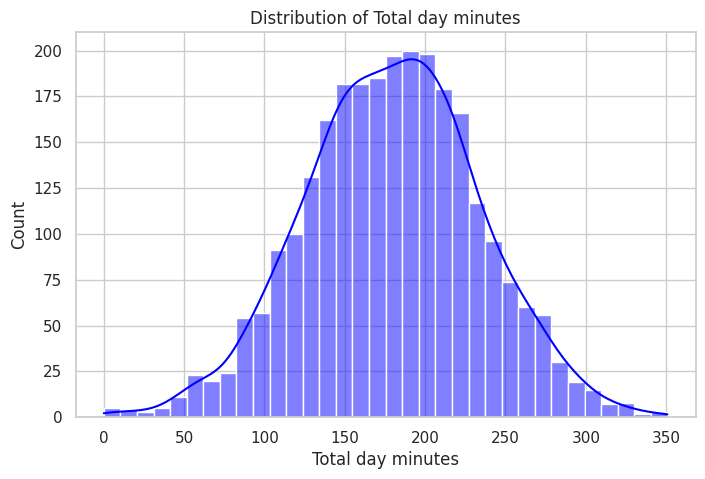

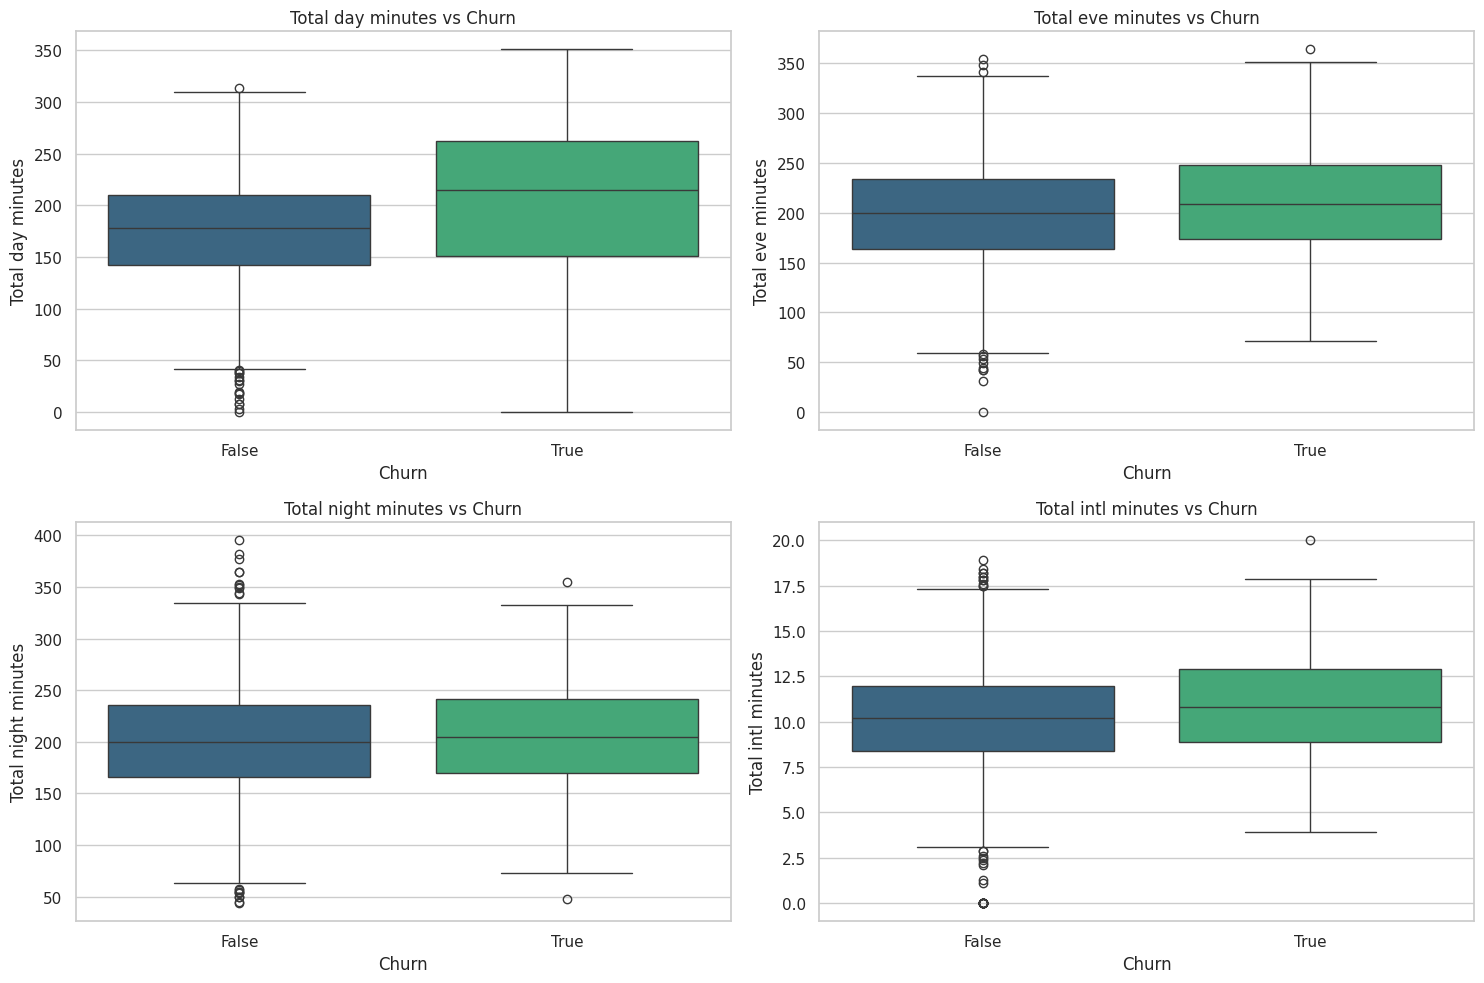

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

plt.figure(figsize=(8,5))
sns.histplot(df['Total day minutes'],kde=True,color='blue')
plt.title('Distribution of Total day minutes')
plt.savefig('distribution_total_day_minutes.png')
plt.show()
plt.figure(figsize=(15,10))
cols_to_plot=['Total day minutes','Total eve minutes', 'Total night minutes','Total intl minutes']
for i,col in enumerate(cols_to_plot):
  plt.subplot(2,2,i+1)
  sns.boxplot(x='Churn', y=col,hue='Churn',data=df,palette='viridis',legend=False)
  plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.savefig('churn_vs_minute_features_boxplots.png')
plt.show()

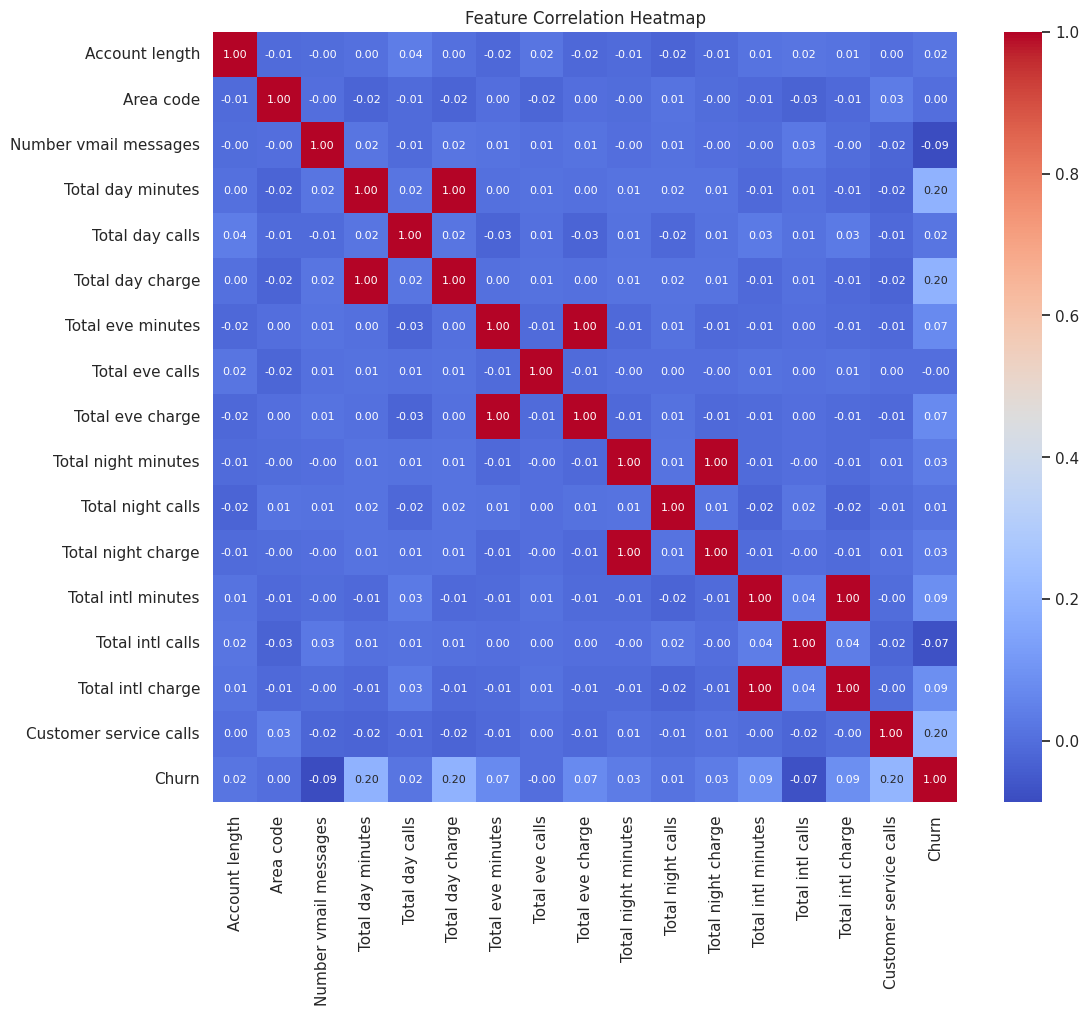

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/churn-bigml-80.csv')
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',annot_kws={'size':8})
plt.title('Feature Correlation Heatmap')
plt.savefig('feature_correlation_heatmap.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
x = df[['Total day minutes']]
y=df['Total day charge']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
predictions = model.predict(x_test)
print(f'R-squared:{r2_score(y_test,predictions):2f}')

R-squared:1.000000


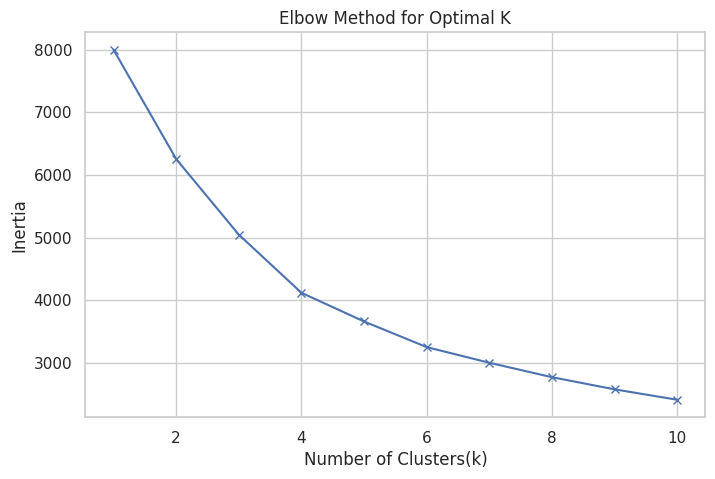

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = df[['Total day minutes','Total eve minutes','Total night minutes']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
inertia = []
K = range(1,11)
for k in K :
  Kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
  Kmeans.fit(scaled_features)
  inertia.append(Kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(K,inertia,'bx-')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('kmeans_elbow_method.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
x= df[['Total day minutes','Total eve minutes','Total night minutes']]
y=df[['Churn']]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
clf=RandomForestClassifier(random_state=42)
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print(classification_report(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

       False       0.88      0.98      0.93       455
        True       0.62      0.23      0.33        79

    accuracy                           0.87       534
   macro avg       0.75      0.60      0.63       534
weighted avg       0.84      0.87      0.84       534



In [ ]:
print(df_encoded.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['Account length', 'Area code', 'Number vmail messages',
       'Total day minutes', 'Total day calls', 'Total day charge',
       'Total eve minutes', 'Total eve calls', 'Total eve charge',
       'Total night minutes', 'Total night calls', 'Total night charge',
       'Total intl minutes', 'Total intl calls', 'Total intl charge',
       'Customer service calls', 'Churn', 'State_AL', 'State_AR', 'State_AZ',
       'State_CA', 'State_CO', 'State_CT', 'State_DC', 'State_DE', 'State_FL',
       'State_GA', 'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN',
       'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME',
       'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC',
       'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV',
       'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI',
       'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'St

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
import pandas as pd
df_encoded = pd.get_dummies(df,drop_first=True)
x= df_encoded.drop('Churn',axis=1)
y=df_encoded['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.92      1.00      0.96       455
        True       0.98      0.51      0.67        79

    accuracy                           0.93       534
   macro avg       0.95      0.75      0.81       534
weighted avg       0.93      0.93      0.91       534



In [ ]:
model = RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
!pip install textblob
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

In [ ]:
def clean_text(text):
 text = re.sub(r'@[A-Za-z0-9]+','',text)
 text = re.sub(r'#','',text)
 text = re.sub(r'RT[\s]+','',text)
 text = re.sub(r'https?://\S',"" ,text)
 return text.lower().strip()

---Sentiment Analysis Results---
                        Customer_Feedback Sentiment
0   The service is amazing and very fast!  Positive
1  I am disapointed with the recent delay   Neutral
2                   Customer care is good  Positive


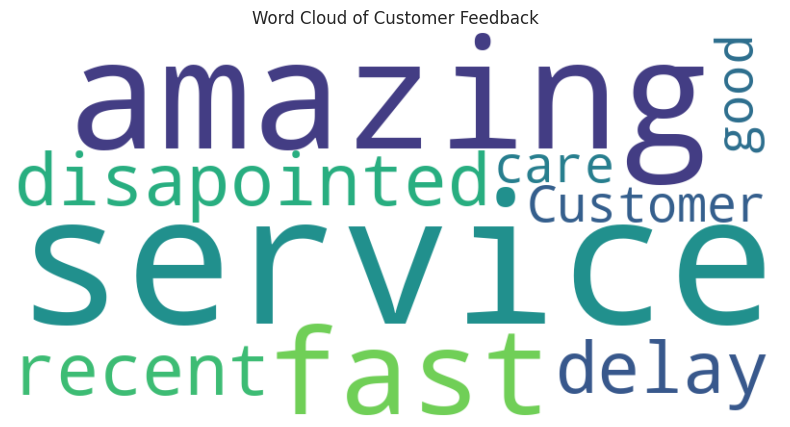

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud

data={'Customer_Feedback':[
    'The service is amazing and very fast!',
    'I am disapointed with the recent delay',
    'Customer care is good'
]}
df_task3 = pd.DataFrame(data)
polarities =[]
for feedback in df_task3['Customer_Feedback']:
  score = TextBlob(str(feedback)).sentiment.polarity
  polarities.append(score)
df_task3['Polarity'] = polarities
def label_sentiment(score):
  if score > 0:return'Positive'
  elif score < 0:return'Negative'
  else:return'Neutral'
df_task3['Sentiment'] = df_task3['Polarity'].apply(label_sentiment)
print('---Sentiment Analysis Results---')
print(df_task3[['Customer_Feedback','Sentiment']])
all_text = ' '.join(df_task3['Customer_Feedback'].astype(str))
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Customer Feedback')
plt.savefig('customer_feedback_wordcloud.png')
plt.show()

In [ ]:
df.t

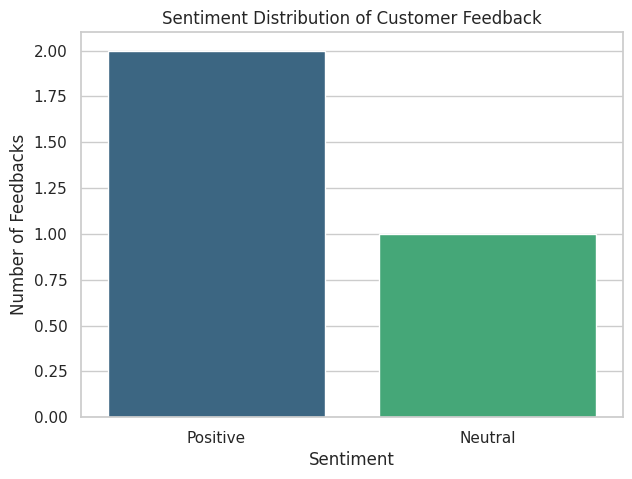

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Sentiment', data=df_task3, hue='Sentiment', palette='viridis', legend=False)
plt.title('Sentiment Distribution of Customer Feedback')
plt.xlabel('Sentiment')
plt.ylabel('Number of Feedbacks')
plt.savefig('sentiment_distribution_countplot.png')
plt.show()

In [ ]:
df.to_csv('cleaned_customer_feedback.csv',index=False)